# 2일차 실습 P5 — 노이즈 입력 · 깨끗한 정답으로 학습

- **맨 위 준비 셀부터** 위에서 아래로 실행
- 셀 실행: 셀을 누르고 **Shift + Enter** 또는 셀 왼쪽 ▶
- Colab 에서 처음 열 때 경고 창이 뜨면 '계속' · 준비 셀을 처음 실행하면 MNIST 를 내려받음
- 빈칸은 `____` · 빈칸을 모두 바꾼 뒤 **그 셀부터 다시 실행**
- 학습 셀은 에폭마다 loss 한 줄씩 찍힘 · `학습 끝` 줄이 찍힐 때까지 기다림
- 막히면 `[안내]` 문장 → **에러 칸 맨 아래 줄** → 힌트 순서로 읽음
- 과제 셀에서 빨간 문법·실행 오류가 나면 확인 셀을 믿지 말 것 · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행할 것

## 에러를 읽는 법

- 에러 칸 첫 줄(`...Error    Traceback ...`)은 제목일 뿐 · 무엇이 틀렸는지는 **맨 아래 줄**
- 중간의 `---->` 화살표 줄 · torch 안쪽 칸은 처음엔 건너뜀 · **위에 찍힌 `[안내]` 문장과 맨 아래 줄부터** 읽음

| 맨 아래 줄에 보이는 말 | 뜻 | 먼저 볼 곳 |
|---|---|---|
| `name '____' is not defined` | 빈칸이 남음 | 화살표가 가리키는 줄 |
| `name 'torch' is not defined` · `name 'nn' is not defined` | 준비 셀을 안 돌렸거나 런타임이 끊김 | 준비 셀부터 순서대로 다시 |
| `name 'Noisy' is not defined` | 내가 친 이름이 틀림 · 대소문자 · 이 셀에서 쓰는 이름은 모두 소문자 | 화살표가 가리키는 줄 |
| `mse_loss() missing 1 required positional argument: 'target'` | 괄호 안 두 자리 가운데 하나만 적음 | (b) 줄의 괄호 안 |

- **에러가 없는데** 확인 셀이 `[안내]` 를 찍으면 → 그 문장이 가리키는 줄부터
- 과제 셀에서 빨간 문법·실행 오류가 나면 확인 셀을 믿지 말 것 · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행할 것
- 학습 셀 맨 아래 줄이 `AssertionError: [안내] 확인 셀에서 …` → 확인 셀을 먼저 · P5-1 셀을 다시 실행했으면 확인 셀도 다시

## 준비

MNIST · 어제와 같은 구조의 오토인코더 · 결과 보기 함수 · 고치지 않고 실행

In [ ]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets

plt.rcParams.update({"figure.facecolor": "#1A222C", "axes.facecolor": "#1A222C", "savefig.facecolor": "#1A222C",   # 그림을 어두운 화면에 맞춤
                     "text.color": "#EEF2F6", "axes.labelcolor": "#EEF2F6", "xtick.color": "#EEF2F6", "ytick.color": "#EEF2F6", "axes.edgecolor": "#5C6A78"})

tr = datasets.MNIST("data", train=True, download=True)
te = datasets.MNIST("data", train=False, download=True)
Xtr = tr.data.float().div(255).unsqueeze(1)   # 학습 60,000장 · 값 0~1
Xte = te.data.float().div(255).unsqueeze(1)   # 평가 10,000장


class AutoEncoder(nn.Module):                 # 어제와 같은 구조: 784 → 128 → 32 → 128 → 784
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, latent_dim))
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 128), nn.ReLU(), nn.Linear(128, 784), nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x)).reshape(-1, 1, 28, 28)


@torch.no_grad()
def run(model, X):                            # 한꺼번에 넣으면 메모리가 커서 2,000장씩
    model.eval()
    return torch.cat([model(X[i:i + 2000]) for i in range(0, len(X), 2000)])


def mse(A):                                   # 평가 10,000장 전체를 원본과 비교
    return F.mse_loss(A, Xte).item()


SHOW = [5459, 9898, 926, 1150, 5691, 2400, 7792, 950]   # 평가 이미지 중 숫자 0~7 한 장씩


def show(rows):
    fig, axes = plt.subplots(len(rows), 8, figsize=(8, 1.15 * len(rows)))
    for r, (name, X) in enumerate(rows):
        for c in range(8):
            axes[r, c].imshow(X[SHOW[c], 0], cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_title(name, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

## P5-1. 노이즈 입력 · 깨끗한 정답

1. 위 **준비** 셀을 실행
2. 아래 셀의 빈칸 두 곳을 채움
   - (a) `noisy` — 깨끗한 숫자 묶음 `x` 에 세기 0.3 가우시안 노이즈를 더하고, 값을 0~1 로 자른 묶음
   - (b) `loss` — 모델에 **무엇을 넣고**, 모델 출력을 **무엇과 비교**하나
3. 실행 → 모양 · 값 범위 · loss 한 줄이 찍힘 → 아래 **확인** 셀 실행 → `노이즈 확인 통과` 가 나오면 P5-2 로 · **P5-1 셀을 다시 실행했으면 확인 셀도 다시**
- 확인 셀이 `[안내]` 를 찍으면 그 문장부터 읽음 · 막히면 코드 셀 아래 **힌트 1** → **힌트 2** 순서로 하나씩 펼침
- 그래도 막히면 확인 셀 아래 **대체 셀**을 실행하고 P5-2 로

In [14]:
import numpy as np

# 문법 예시 (이 실습의 답 아님)
#   t + 0.5 * torch.randn_like(t)   → t 와 같은 모양 · 칸마다 평균 0 · 세기 0.5 인 무작위 값을 더한 묶음
#   (t * 2).clamp(0, 1)             → 0 보다 작은 값은 0 · 1 보다 큰 값은 1 로 자른 묶음
#   F.mse_loss(a, b)                → a 와 b 의 칸마다 차이를 제곱해 평균 낸 값 하나

dae_loss = noisy = loss = None              # 이 셀을 실행할 때마다 이전 결과를 지움 · 고치지 않음
노이즈_통과 = 대체_사용 = False               # 확인 셀 통과 표시 · 대체 셀 사용 표시 · 고치지 않음


def dae_loss(model, x):                     # 깨끗한 숫자 묶음 x 한 묶음 → (노이즈 입력, loss)
    noisy = (x + 0.3 * torch.randn_like(x)).clamp(0, 1) # (a) 노이즈 입력
    loss = F.mse_loss(model(noisy), x)                # (b) loss
    return noisy, loss


torch.manual_seed(0)
noisy, loss = dae_loss(AutoEncoder(), Xtr[:8])   # 학습 전 모델 · 학습 이미지 8장으로 한 번 불러 봄
print("x", tuple(Xtr[:8].shape), " noisy", tuple(noisy.shape), f" noisy 값 범위 {noisy.min().item():.2f}~{noisy.max().item():.2f}", f" loss {loss.item():.4f}")

x (8, 1, 28, 28)  noisy (8, 1, 28, 28)  noisy 값 범위 0.00~1.00  loss 0.2314


<details><summary><b>힌트 1</b> — 막힐 때만 펼침</summary>

- (a) 위 문법 예시 첫 두 줄을 이어 씀 · 바꿀 것: 묶음 이름(`t` → `x`) · 노이즈 세기 · 0~1 로 자르는 것은 노이즈를 **더한 결과 전체**
- (b) 모델에 넣는 것 = 학습 때 모델이 받게 될 입력 · 비교하는 정답 = 모델이 내놓기를 바라는 것 · 노이즈 낀 숫자를 넣으면 어떤 숫자가 나오기를 바라나

</details>

<details><summary><b>힌트 2</b> — 힌트 1 로도 막힐 때</summary>

- (a) `(x + 0.3 * torch.randn_like(x)).clamp(0, 1)`
- (b) `F.mse_loss(model(noisy), x)` · 모델에 넣는 것은 `noisy` · 비교하는 정답은 깨끗한 `x`

</details>

In [15]:
# P5-1 확인 — 노이즈 입력 · loss 검사 · 고치지 않고 실행만 · 읽지 않아도 됨
# 약속(수업 설명과 같음): 노이즈 = 평균 0 가우시안 · 세기 0.3 · 더한 뒤 0~1 로 자름 · loss = 노이즈 입력을 넣은 모델 출력과 깨끗한 원본의 평균 제곱 오차
def 과제_문법_검사(*표시):                       # 과제 셀을 마지막으로 실행한 글자에 문법 오류가 있었는지 · 실행 기록(In)이 없으면 통과하지 않음
    기록 = globals().get("In")
    if not isinstance(기록, list) or len(기록) < 2:
        return False
    for 표 in 표시:
        for src in reversed(기록[:-1]):
            if 표 in src and "def 과제_문법_검사" not in src:
                try:
                    compile(src, "<과제 셀>", "exec")
                except SyntaxError:
                    return False
                break
    return True


import math


class 검사용_모델(nn.Module):                   # 입력 × 0.8 + 0.1 을 내보냄 · 무엇을 넣었는지가 출력에 드러남
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(0.8))

    def forward(self, t):
        return self.a * t + 0.1


def 노이즈_검사(dae_loss, noisy, loss):
    if dae_loss is None or noisy is None or loss is None:
        return "[안내] 위 P5-1 셀이 끝까지 실행되지 않았음 → 빈칸 ____ 두 곳을 모두 바꾸고 위 셀부터 다시 실행 · 준비 셀을 안 돌렸으면 그것부터"
    x = Xtr[:512]                                # 검사용 묶음 · 학습 이미지 앞 512장
    probe = 검사용_모델()
    try:
        n, l = dae_loss(probe, x)
    except Exception as e:
        return f"[안내] 확인 셀이 P5-1 함수를 다시 불러 보다 멈춤({type(e).__name__}) → P5-1 셀의 빈칸 두 줄부터"
    if not torch.is_tensor(n) or tuple(n.shape) != tuple(x.shape):
        return "[안내] noisy 가 x 와 같은 모양의 텐서가 아님 → (a) 는 x 와 같은 모양의 묶음"
    n = n.detach()
    if torch.equal(n, x):
        return "[안내] noisy 가 x 와 똑같음 → 노이즈를 더하지 않았음"
    if n.min().item() < 0 or n.max().item() > 1:
        return "[안내] noisy 에 0 보다 작거나 1 보다 큰 값이 있음 → 노이즈를 더한 결과 전체를 0~1 로 자르는 부분이 빠졌음"
    bg = n[x == 0]                               # 원본이 0(검은 바탕)인 칸 · 0~1 로 자르고 나면 노이즈의 양수 쪽만 남음
    if not 0.45 < (bg > 0).float().mean().item() < 0.55:
        return "[안내] 노이즈 종류가 약속과 다름 → 평균 0 가우시안(음수와 양수가 반씩 나오는 무작위 값)"
    if not 0.28 < bg.mean().item() * math.sqrt(2 * math.pi) < 0.32:
        return "[안내] 노이즈 세기가 약속(0.3)과 다름 → 무작위 값에 곱하는 수"
    if not torch.is_tensor(l) or l.dim() != 0:
        return "[안내] loss 가 값 하나인 텐서가 아님 → (b) 는 평균 제곱 오차 하나"
    if not l.requires_grad:
        return "[안내] 이 loss 로는 학습할 수 없음(모델 출력으로 계산하지 않았음) → (b) 괄호 안에 모델 출력"
    with torch.no_grad():
        기준 = F.mse_loss(probe(n), x).item()
        정답이_noisy = F.mse_loss(probe(n), n).item()
        입력이_x = F.mse_loss(probe(x), x).item()
    v = l.item()
    if abs(v - 기준) <= 1e-5 * 기준:
        return "노이즈 확인 통과"
    if abs(v - 정답이_noisy) <= 1e-5 * 정답이_noisy:
        return "[안내] loss 의 정답 자리에 noisy 가 들어감 → 노이즈 낀 숫자를 노이즈 낀 그대로 되돌리는 연습이 됨 · 정답 자리에는 깨끗한 원본"
    if abs(v - 입력이_x) <= 1e-5 * 입력이_x:
        return "[안내] 모델에 깨끗한 x 를 넣었음 → 학습 때 모델이 받는 것은 노이즈 입력"
    return "[안내] loss 가 '노이즈 입력을 넣은 모델 출력 ↔ 깨끗한 원본' 의 평균 제곱 오차와 다름 → (b) 괄호 안 두 자리"


try:
    결과 = 노이즈_검사(dae_loss, noisy, loss) if 과제_문법_검사('dae_loss = noisy = loss = None') else "[안내] 과제 셀의 정상 실행을 확인할 수 없음(문법 오류 또는 실행 기록 없음) · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행 · 계속되면 런타임을 다시 시작하고 준비부터 실행"
except NameError:
    print("[안내] 위 P5-1 셀이 끝까지 실행되지 않았음 → 빈칸 ____ 두 곳을 모두 바꾸고 위 셀부터 다시 실행 · 준비 셀을 안 돌렸으면 그것부터")
    raise
노이즈_통과 = 결과 == "노이즈 확인 통과"          # 통과를 찍을 때만 True · 학습 셀이 이 값을 봄
노이즈_출처 = "대체 셀" if 대체_사용 else "직접 만든 함수"
print(결과)

노이즈 확인 통과


### 대체 셀 — 확인 셀이 `[안내]` 를 찍었고 막혔을 때만 실행

- P5-1 과 같은 일을 하는 `dae_loss` 를 다른 방법으로 만듦 · 실행하면 P5-2 로 넘어갈 수 있음
- `노이즈 확인 통과` 가 나왔으면 실행하지 않음 · 실행하면 내가 만든 함수를 덮어쓰고 학습 셀 첫 줄에 `loss 함수: 대체 셀` 이 찍힘

In [ ]:
# 대체 셀 — 막혔을 때만 · P5-1 과 같은 일을 하는 dae_loss 를 다른 방법으로 만듦
def dae_loss(model, x):
    noise = torch.randn_like(x).mul(0.3)                   # 세기 0.3 가우시안
    noisy = torch.clamp(x + noise, min=0.0, max=1.0)       # 더한 결과를 0~1 로 자름
    return noisy, F.mse_loss(input=model(noisy), target=x)


torch.manual_seed(0)
noisy, loss = dae_loss(AutoEncoder(), Xtr[:8])
print("대체 셀 · noisy", tuple(noisy.shape), f" noisy 값 범위 {noisy.min().item():.2f}~{noisy.max().item():.2f}", f" loss {loss.item():.4f}")
노이즈_통과, 대체_사용, 노이즈_출처 = True, True, "대체 셀"   # 대체 셀로 만든 함수라는 표시 · P5-1 셀을 다시 실행하면 지워짐

## P5-2. 학습 · 결과 보기

아래 세 셀은 **고치지 않고** 차례로 실행 · 확인 셀 통과(또는 대체 셀) 뒤에만 돎

1. **학습**: 어제와 같은 구조의 오토인코더를 새로 만들어 학습 이미지 60,000장으로 2 에폭 · 에폭마다 loss 한 줄 · 첫 줄에 loss 함수 출처
2. **그림**: 평가 이미지 8장 · 줄마다 original · noisy input · my model
3. **숫자**: `노이즈 입력 그대로` · `내 모델` MSE 두 줄(평가 이미지 10,000장 · 원본과의 차이 · 작을수록 원본에 가까움)
- 정상: 그림의 my model 줄에서 숫자 모양이 보이고, 내 모델 MSE 가 노이즈 입력 그대로보다 작음
- 학습 셀이 `[안내]` 를 찍으면 → P5-1 확인 셀부터 다시

In [16]:
# 학습 — 학습 이미지 60,000장 · 2 에폭 · 한 묶음 128장 · 확인 셀 통과 뒤에만
assert globals().get("노이즈_통과"), "[안내] 확인 셀에서 '노이즈 확인 통과' 를 받은 뒤 실행 · P5-1 셀을 다시 실행했으면 확인 셀도 다시 · 막히면 대체 셀"
print("loss 함수:", 노이즈_출처)
torch.manual_seed(0)
my_model = AutoEncoder()                          # 어제와 같은 구조 · 새로 시작
opt = torch.optim.Adam(my_model.parameters(), lr=1e-3)
for epoch in range(2):
    my_model.train()
    perm = torch.randperm(len(Xtr))
    total = 0.0
    for i in range(0, len(Xtr), 128):
        x = Xtr[perm[i:i + 128]]
        opt.zero_grad()
        noisy, loss = dae_loss(my_model, x)       # P5-1 에서 만든 함수 · 묶음마다 새 노이즈
        loss.backward()
        opt.step()
        total += loss.item() * len(x)
    print(f"에폭 {epoch + 1}  loss {total / len(Xtr):.4f}")
print("학습 끝")

loss 함수: 직접 만든 함수
에폭 1  loss 0.0530
에폭 2  loss 0.0261
학습 끝


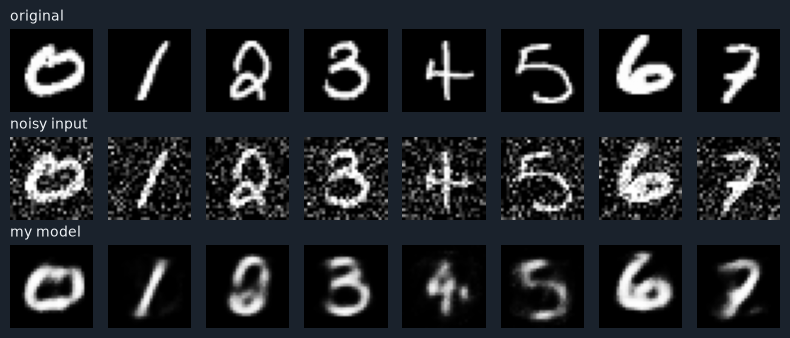

In [24]:
# 그림 — 평가 이미지 10,000장에 노이즈를 한 번 입힘(seed 999) → 내 모델에 넣음 · 줄마다 original · noisy input · my model
assert globals().get("노이즈_통과"), "[안내] 확인 셀에서 '노이즈 확인 통과' 를 받은 뒤 실행 · P5-1 셀을 다시 실행했으면 확인 셀도 다시 · 막히면 대체 셀"
torch.manual_seed(999)
with torch.no_grad():
    Xte_noisy, _ = dae_loss(my_model, Xte)        # P5-1 함수의 노이즈 줄로 평가 이미지 전체에 노이즈
noisy_in_out_mine = run(my_model, Xte_noisy)
show([("original", Xte), ("noisy input", Xte_noisy), ("my model", noisy_in_out_mine)])

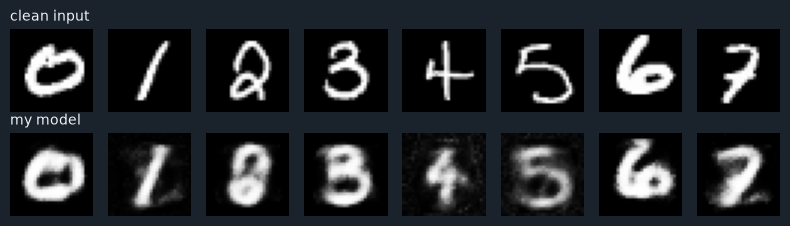

In [25]:
# 노이즈로 학습시킨 모델에 깨끗한 입력을 주면?
torch.manual_seed(999)
clean_in_out_mine = run(my_model, Xte)
show([("clean input", Xte), ("my model", clean_in_out_mine)])

In [26]:
# 숫자 — 평가 이미지 10,000장 전체를 원본과 비교한 MSE · 작을수록 원본에 가까움
assert globals().get("노이즈_통과"), "[안내] 확인 셀에서 '노이즈 확인 통과' 를 받은 뒤 실행 · P5-1 셀을 다시 실행했으면 확인 셀도 다시 · 막히면 대체 셀"
print(f"noisy image <-> clean image:                         MSE {mse(Xte_noisy):.3f}   (평가 이미지 10,000장)")
print(f"prediction given noisy_input <-> clean image:        MSE {mse(noisy_in_out_mine):.3f}   (평가 이미지 10,000장)")
print(f"prediction given clean_input <-> clean image         MSE {mse(clean_in_out_mine):.3f}   (평가 이미지 10,000장)")

noisy image <-> clean image:                         MSE 0.047   (평가 이미지 10,000장)
prediction given noisy_input <-> clean image:        MSE 0.022   (평가 이미지 10,000장)
prediction given clean_input <-> clean image         MSE 0.042   (평가 이미지 10,000장)


## P5 마무리 — 세 줄 적기 (채점 아님)

이 칸을 두 번 눌러 `→` 뒤에 적음

1. loss 의 정답 자리에 noisy 가 아니라 깨끗한 x 를 두는 까닭 → DAE는 학습 방법일 뿐. 정답에도 노이즈낀 걸 주면 노이즈낀 걸 출력하도록 학습이 되기 때문.
2. 정답 자리가 맞게 들어갔다는 것을 무엇으로 확인했나(그림 말고) → 깨끗한 이미지를 주고 학습한 것 보다 loss가 더 낮음
3. 노이즈 없는 깨끗한 숫자를 내 모델에 넣으면 출력이 어떨지 예상 → 예측: 좋게 나올 것 같은데? 실제: 더 나쁘게 나옴. 노이즈가 낀 loss랑 거의 차이가 없음. 결론: 노이즈 껴서 학습시켰으면 예측에도 노이즈 껴서 줘야 함. 
4. 대체 셀을 썼나 · 썼다면 어디서 막혔나 →